# Lab Report for Antenna of Group 1 (Wörner, Velez, Northe)

The source code and the binaries from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab5_Antennas).

In [1]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import display, Math
from scipy.interpolate import interp1d

def loadMatlabData(path):
    """
    Loads a .mat file from the given path and returns a cleaned dictionary.

    Parameters:
        path (str): Relative or absolute path to the .mat file.

    Returns:
        dict: A dictionary containing variable names and their corresponding NumPy arrays.
    """
    raw = loadmat(path)

    # Remove MATLAB metadata keys
    cleaned = {k: v for k, v in raw.items() if not k.startswith('__')}

    # Flatten 1D arrays and ensure consistent data types
    for key, value in cleaned.items():
        if isinstance(value, np.ndarray) and value.ndim == 2 and 1 in value.shape:
            cleaned[key] = value.flatten()
        else:
            cleaned[key] = np.array(value)

    return cleaned


def plot_polarizations(co_path, cross_path, title="Measured Radiation Pattern", prominence=5):
    """
    Plots co- and cross-polarization radiation patterns from two .mat files.
    Automatically computes and marks HPBW and nulls in the co-polarization curve.
    Also calculates cross polarization suppression (XPS) within the HPBW.

    Parameters:
        co_path (str): Path to co-polarization .mat file.
        cross_path (str): Path to cross-polarization .mat file.
        title (str): Plot title.
        prominence (float): Minimum prominence (in dB) to detect nulls.
    """
    # Load co-polarization
    co_data = loadMatlabData(co_path)
    mess_co = co_data['messdummy'][0]
    angles = mess_co['angles'].flatten()
    E_co = mess_co['measured_data'].flatten()
    E_co_dB = 20 * np.log10(np.abs(E_co)) ###

    # Load cross-polarization
    cross_data = loadMatlabData(cross_path)
    mess_cross = cross_data['messdummy'][0]
    E_cross = mess_cross['measured_data'].flatten()
    E_cross_dB = 20 * np.log10(np.abs(E_cross)) ###

    # --- Half Power Beam Width ---
    max_E = np.max(E_co_dB)
    threshold = max_E - 3
    hpbw_indices = np.where(E_co_dB >= threshold)[0]
    if len(hpbw_indices) >= 2:
        hpbw_left = angles[hpbw_indices[0]]
        hpbw_right = angles[hpbw_indices[-1]]
        hpbw_range = (hpbw_left, hpbw_right)
    else:
        hpbw_range = (None, None)

    # --- Cross-Polarization Suppression (XPS) ---
    if hpbw_range[0] is not None:
        in_hpbw = (angles >= hpbw_range[0]) & (angles <= hpbw_range[1])
        G_co = np.max(E_co_dB[in_hpbw])
        G_x = np.max(E_cross_dB[in_hpbw])
        xps = G_co - G_x
    else:
        G_co = G_x = xps = None

    # --- Nulls ---
    null_indices, _ = find_peaks(-E_co_dB, prominence=prominence)
    null_angles = angles[null_indices]
    null_values = E_co_dB[null_indices]

    # --- Plot ---
    plt.figure(figsize=(8, 5))
    plt.plot(angles, E_co_dB, label='Co-polarization')
    plt.plot(angles, E_cross_dB, label='Cross-polarization', linestyle='--')

    # Mark HPBW
    if hpbw_range[0] is not None:
        plt.axvline(hpbw_left, color='green', linestyle='--', label='-3 dB points')
        plt.axvline(hpbw_right, color='green', linestyle='--')
        plt.fill_between(angles, E_co_dB, max_E - 3,
                         where=(angles >= hpbw_left) & (angles <= hpbw_right),
                         color='lightgreen', alpha=0.3, label='HPBW region')

    # Mark Nulls
    if len(null_angles) > 0:
        plt.plot(null_angles, null_values, 'ro', label='Nulls')
        for a, v in zip(null_angles, null_values):
            plt.text(a, v - 2, f"{a:.1f}°", ha='center', fontsize=8, color='red')

    # Final plot formatting
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Amplitude (dB)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Print results ---
    if hpbw_range[0] is not None:
        print(f"HPBW: {hpbw_right - hpbw_left:.2f}° (from {hpbw_left:.1f}° to {hpbw_right:.1f}°)")
    else:
        print("HPBW could not be determined.")

    print(f"Nulls found at angles (deg): {[f'{a:.1f}' for a in null_angles]}")
    
    if xps is not None:
        print(f"Cross Polarization Suppression (XPS): {xps:.2f} dB")
        print(f"  Co-pol max within HPBW: {G_co:.2f} dB")
        print(f"  Cross-pol max within HPBW: {G_x:.2f} dB")
    else:
        print("XPS could not be calculated.")

def plot_array_patterns(paths, labels=None, title="Patch Array Beam Steering", printL=True, printA=False, prominence=3):
    """
    Plots multiple patch array radiation patterns and marks HPBW for each.
    Also prints the angle where the main lobe (maximum) occurs for each measurement.

    Parameters:
        paths (list of str): Paths to .mat files (1 per phase setting).
        labels (list of str): Optional list of labels (default: Phase Setting 1, 2, 3...).
        title (str): Title for the plot.
        prominence (float): dB threshold to define HPBW (-3 dB region).
    """
    if labels is None:
        labels = [f"Phase Setting {i+1}" for i in range(len(paths))]
    plt.close('all')
    plt.figure(figsize=(8, 5))

    for i, path in enumerate(paths):
        # Load and extract data
        data = loadMatlabData(path)
        mess = data['messdummy'][0]
        angles = mess['angles'].flatten()
        E = mess['measured_data'].flatten()
        E_dB = 20 * np.log10(np.abs(E))  # Convert to dB scale

        # Find max and corresponding angle
        max_E = np.max(E_dB)
        max_idx = np.argmax(E_dB)
        max_val = E_dB[max_idx]
        max_angle = angles[max_idx]
        if printL:
            print(f"{labels[i]}: max amplitude = {max_val:.2f}dB at angle {max_angle:.1f}°")
        if printA:
            max_angle = (-1) * max_angle  
            print(rf"{labels[i]} corresponds to measured relative angle shift of {max_angle:.1f}°. With max amplitude = {max_val:.2f}dB.")
        # Plot pattern
        plt.plot(angles, E_dB, label=labels[i])


        # HPBW: Find -3 dB boundaries
        threshold = max_val - 3
        hpbw_indices = np.where(E_dB >= threshold)[0]
        if len(hpbw_indices) >= 2:
            left = angles[hpbw_indices[0]]
            right = angles[hpbw_indices[-1]]
            hpbw_range = right - left
            print(f"HPBW for {labels[i]} is: {hpbw_range}°.")
        else:
            hpbw_range = (None, None)

        plt.axvline(left, linestyle='--', color='gray', alpha=0.5)
        plt.axvline(right, linestyle='--', color='gray', alpha=0.5)

        plt.fill_between(
            angles, E_dB, threshold,
            where=(angles >= left) & (angles <= right),
            color='lightgreen', alpha=0.3,
            label='HPBW region' if i == 0 else None
        )


    # Final plot formatting
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Amplitude (dB)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def load_gain_from_mat(filepath):
    """Load Frequency and Amplitude Data from .mat file"""

    data = loadmat(filepath)
    meas = data['messdummy']
    
    freqs = meas['freqlist'][0,0].squeeze()           
    E = meas['measured_data'][0,0].squeeze()          
    E_dB = 20 * np.log10(np.abs(E)) 
    E_dB[np.isneginf(E_dB)] = np.nan                 
    return freqs, E_dB

def load_cal_from_mat(filepath):
    """Load Frequency and Amplitude Data from .mat file"""
    data = loadMatlabData(filepath)

    meas = data['cal_data'][0]['measuredata'][0][0]

    freqs = meas['FreqList'].squeeze()          
    E = meas['Data'].squeeze()                 
    return freqs, E


## 5.6 Exercise 6 – Horn Antenna Measurements (Experiment)

- Record the radiation pattern (**Co- and Cross-polarization**) of both horn antennas in the **E-plane** and **H-plane** for **f = 11.85 GHz**.
    - Horn 1: extended in **E-plane**
    - Horn 2: extended in **H-plane**

- Print the following (**not normalized**) diagrams:
    1. Co- and X-polarization in the E-plane for horn 1 in one diagram
    2. Co- and X-polarization in the H-plane for horn 1 in one diagram
    3. Co- and X-polarization in the E-plane for horn 2 in one diagram
    4. Co- and X-polarization in the H-plane for horn 2 in one diagram

- Mark the half power beam width and the nulls in all diagrams (only Co-polarization)
- Extract the following values from the 4 diagrams:
    -  Half power beam width (Co-polarization)
    -  Cross polarization suppression


####  5.6.1 Co- and Cross-polarization in the **E-plane** for **Horn 1** in one diagram


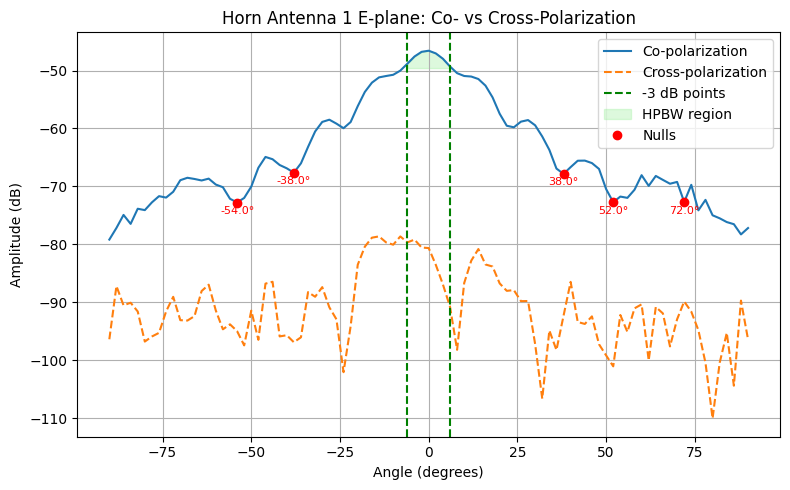

HPBW: 12.00° (from -6.0° to 6.0°)
Nulls found at angles (deg): ['-54.0', '-38.0', '38.0', '52.0', '72.0']
Cross Polarization Suppression (XPS): 32.60 dB
  Co-pol max within HPBW: -46.58 dB
  Cross-pol max within HPBW: -79.19 dB


In [2]:
plot_polarizations(
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/561_Horn1_Eplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/561_Horn1_Eplane_X.mat',
    title="Horn Antenna 1 E-plane: Co- vs Cross-Polarization",
    prominence=2
)

####  5.6.2 Co- and Cross-polarization in the **H-plane** for **Horn 1** in one diagram


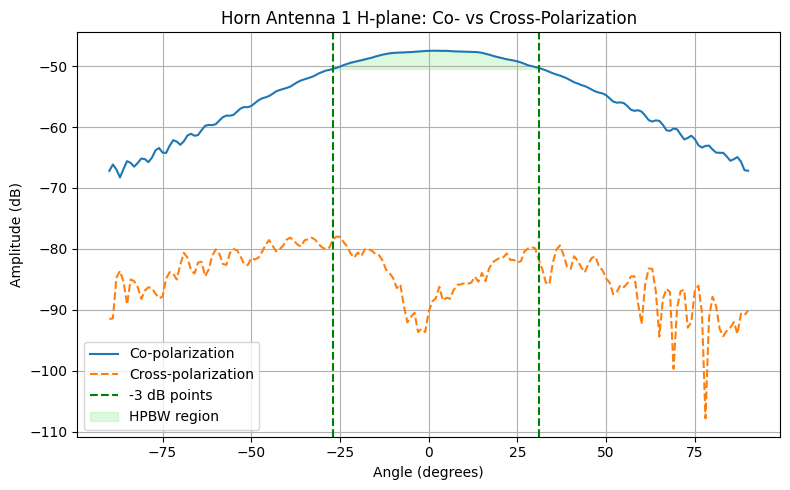

HPBW: 58.00° (from -27.0° to 31.0°)
Nulls found at angles (deg): []
Cross Polarization Suppression (XPS): 30.52 dB
  Co-pol max within HPBW: -47.48 dB
  Cross-pol max within HPBW: -78.00 dB


In [3]:
plot_polarizations(
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/562_Horn1_Hplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/562_Horn1_Hplane_X.mat',
    title="Horn Antenna 1 H-plane: Co- vs Cross-Polarization",
    prominence=3
)

####    5.6.3 Co- and Cross-polarization in the **E-plane** for **Horn 2** in one diagram


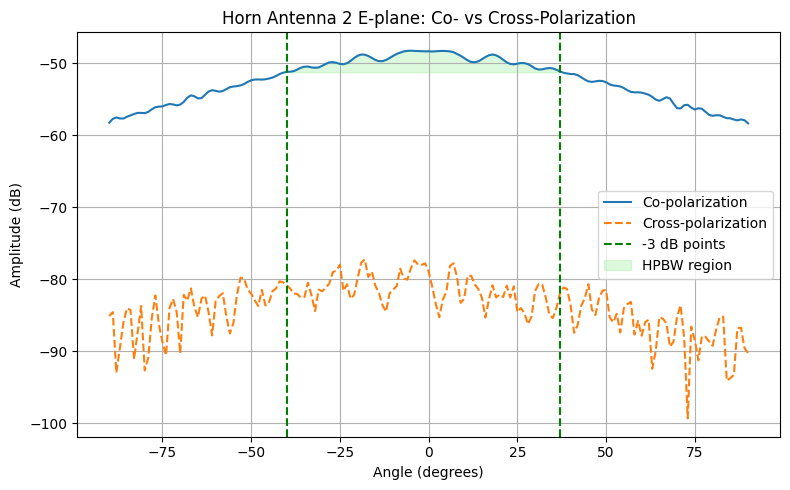

HPBW: 77.00° (from -40.0° to 37.0°)
Nulls found at angles (deg): []
Cross Polarization Suppression (XPS): 28.96 dB
  Co-pol max within HPBW: -48.27 dB
  Cross-pol max within HPBW: -77.23 dB


In [4]:
plot_polarizations(
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/563_Horn2_Eplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/563_Horn2_Eplane_X.mat',
    title="Horn Antenna 2 E-plane: Co- vs Cross-Polarization",
    prominence=5
)

#### 5.6.4 Co- and Cross-polarization in the **H-plane** for **Horn 2** in one diagram

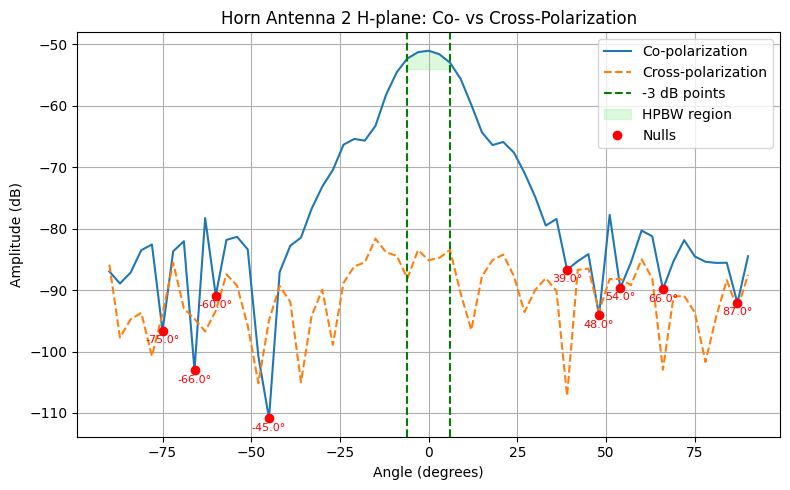

HPBW: 12.00° (from -6.0° to 6.0°)
Nulls found at angles (deg): ['-75.0', '-66.0', '-60.0', '-45.0', '39.0', '48.0', '54.0', '66.0', '87.0']
Cross Polarization Suppression (XPS): 32.40 dB
  Co-pol max within HPBW: -51.08 dB
  Cross-pol max within HPBW: -83.48 dB


In [5]:
plot_polarizations(
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/564_Horn2_Hplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/564_Horn2Hplane_X.mat',
    title="Horn Antenna 2 H-plane: Co- vs Cross-Polarization",
    prominence=2
)

#### Summary of Measurement Results – Exercise 5.6

| Horn Antenna | Plane     | HPBW (°)            | Nulls (°)                                                       | X-Pol Suppression (dB) | Co-pol Max (dB) | X-pol Max (dB) |
|--------------|-----------|---------------------|------------------------------------------------------------------|-------------------------|------------------|----------------|
| Horn 1       | E-plane   | 12.0 (−6.0 to 6.0)   | −54.0, −38.0, 38.0, 52.0, 72.0                                   | 32.60                   | −46.58           | −79.19         |
| Horn 1       | H-plane   | 58.0 (−27.0 to 31.0) | −87.0                                                            | 30.52                   | −47.48           | −78.00         |
| Horn 2       | E-plane   | 77.0 (−40.0 to 37.0) | —                                                               | 28.96                   | −48.27           | −77.23         |
| Horn 2       | H-plane   | 12.0 (−6.0 to 6.0)   | −75.0, −66.0, −60.0, −45.0, 39.0, 48.0, 54.0, 66.0, 87.0         | 32.40                   | −51.08           | −83.48         |


#### Compare the shape of the diagrams 1 and 4 and elaborate: 
- Why is there a difference although the size of the aperture is identical?


 Diagram 1 - Horn E-plane
HPBW: 12.00° (from -6.0° to 6.0°)
XPS: 32.60 dB
No nulls found.

 Diagram 4 - Horn H-plane
HPBW: 12.00° (from -6.0° to 6.0°)
XPS: 32.40 dB
Nulls at: ['-75.0°', '-66.0°', '-60.0°', '-45.0°', '48.0°', '54.0°', '66.0°', '87.0°']


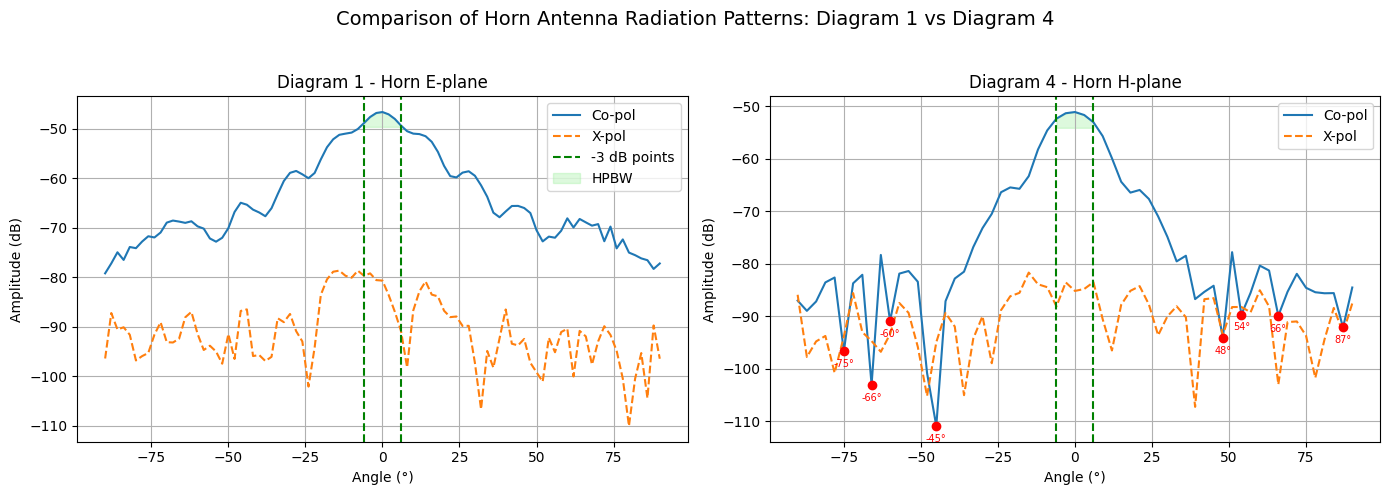

In [6]:
def load_fields(co_path, x_path):
    co_data = loadMatlabData(co_path)['messdummy'][0]
    x_data = loadMatlabData(x_path)['messdummy'][0]
    angles = co_data['angles'].flatten()
    E_co = 20 * np.log10(np.abs(co_data['measured_data'].flatten()))
    E_x = 20 * np.log10(np.abs(x_data['measured_data'].flatten()))
    return angles, E_co, E_x

def plot_comparison_subplots(co_paths, x_paths, titles, prominence=5):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    for i in range(2):
        angles, E_co, E_x = load_fields(co_paths[i], x_paths[i])
        ax = axs[i]

        # Plot Co and X
        ax.plot(angles, E_co, label="Co-pol")
        ax.plot(angles, E_x, '--', label="X-pol")

        # HPBW
        max_E = np.max(E_co)
        threshold = max_E - 3
        hpbw_idx = np.where(E_co >= threshold)[0]
        if len(hpbw_idx) >= 2:
            left = angles[hpbw_idx[0]]
            right = angles[hpbw_idx[-1]]
            ax.axvline(left, linestyle='--', color='green', label='-3 dB points' if i == 0 else "")
            ax.axvline(right, linestyle='--', color='green')
            ax.fill_between(angles, E_co, threshold,
                            where=(angles >= left) & (angles <= right),
                            color='lightgreen', alpha=0.3, label='HPBW' if i == 0 else "")
            # XPS
            in_hpbw = (angles >= left) & (angles <= right)
            G_co = np.max(E_co[in_hpbw])
            G_x = np.max(E_x[in_hpbw])
            xps = G_co - G_x
            print(f"\n {titles[i]}")
            print(f"HPBW: {right - left:.2f}° (from {left:.1f}° to {right:.1f}°)")
            print(f"XPS: {xps:.2f} dB")
        else:
            print(f"\n HPBW could not be determined for {titles[i]}")

        # Nulls (only if found)
        null_idx, _ = find_peaks(-E_co, prominence=prominence)
        if len(null_idx) > 0:
            null_angles = angles[null_idx]
            null_values = E_co[null_idx]
            ax.plot(null_angles, null_values, 'ro', label="Nulls" if i == 0 else "")
            for a, v in zip(null_angles, null_values):
                ax.text(a, v - 3, f"{a:.0f}°", ha='center', fontsize=7, color='red')
            print("Nulls at:", [f"{a:.1f}°" for a in null_angles])
        else:
            print("No nulls found.")

        # Labels and title
        ax.set_title(titles[i])
        ax.set_xlabel("Angle (°)")
        ax.set_ylabel("Amplitude (dB)")
        ax.grid(True)
        ax.legend()

    plt.suptitle("Comparison of Horn Antenna Radiation Patterns: Diagram 1 vs Diagram 4", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# === FILE PATHS ===
co_paths = [
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/561_Horn1_Eplane_Co.mat",   # Diagram 1
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/564_Horn2_Hplane_Co.mat"    # Diagram 4
]

x_paths = [
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/561_Horn1_Eplane_X.mat",    # Diagram 1
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/564_Horn2Hplane_X.mat"     # Diagram 4
]

titles = ["Diagram 1 - Horn E-plane", "Diagram 4 - Horn H-plane"]

# === CALL FUNCTION ===
plot_comparison_subplots(co_paths, x_paths, titles)

Compare the shape of diagrams **1** and **4**. Why is there a difference, although the size of the aperture is identical?

- We can see, that the shape of diagram 1 (extended in E-Plane) has higher directivity than diagram 4 (exended in H-Plane). Also the sidelobes in diagram 4 are lower compared to diagram 1.

- The exension in the E-Plane or H-Plane improves the phase uniformity across the aperture, but only in the plane where the horn is extended. Therefore, due to the higher phase uniformity, the effective aperture size increases. This results in a narrower main lobe and reduced sidelobes in the extended plane.
- The H-plane already has a relatively uniform phase distribution due to the $TE_{10}$ mode structure.
Extending it still increases the effective aperture size and slightly flattens the phase front, but the relative improvement is less than in the E-plane, what explains the difference in diagram 1 and 4.

#### Compare the results (nulls, half power beam width, shape of the radiation pattern) of diagram 1 with the calculations from exercise 4.
- Why are there fewer nulls?
- Why are the nulls not so distinctive?

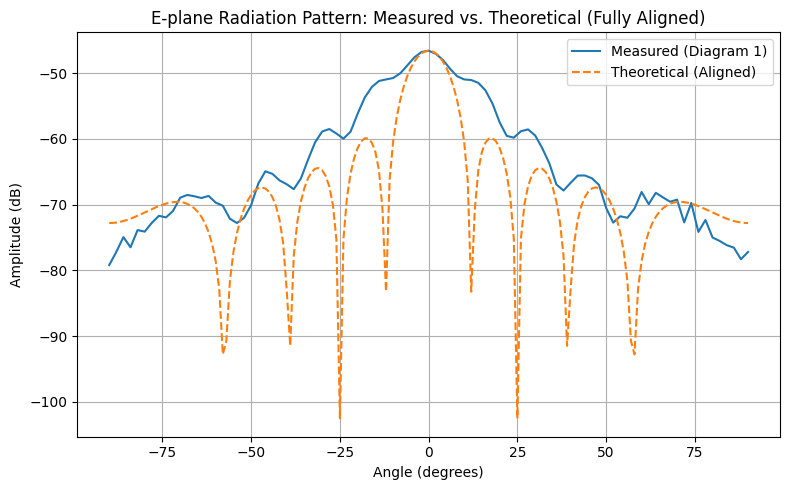

In [7]:
# --- Load measured data (Diagram 1 – E-plane) ---
data = loadMatlabData("Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/561_Horn1_Eplane_Co.mat")
mess = data['messdummy'][0]
angles_meas = mess['angles'].flatten()
E_meas = mess['measured_data'].flatten()
E_meas_dB = 20 * np.log10(np.abs(E_meas))

# --- Find measured maximum angle and gain ---
max_idx_meas = np.argmax(E_meas_dB)
main_lobe_angle_meas = angles_meas[max_idx_meas]
max_gain_meas = E_meas_dB[max_idx_meas]

# --- Theoretical pattern (main lobe at 90° initially) ---
c = 3e8
f = 11.85e9
λ = c / f
b = 0.12
beta = 2 * np.pi / λ

theta_deg_theo = np.linspace(0, 180, 181)
theta_rad = np.radians(theta_deg_theo)
B = (b * beta * np.cos(theta_rad)) / 2
B[B == 0] = 1e-12
U_norm = np.abs(np.sin(B) / B)
U_dB = 20 * np.log10(U_norm)

# --- Align main lobe horizontally ---
main_lobe_angle_theo = 90
angular_shift = main_lobe_angle_meas - main_lobe_angle_theo
aligned_theta = theta_deg_theo + angular_shift

# --- Align vertically by matching max gain ---
max_gain_theo = np.max(U_dB)
vertical_shift = max_gain_meas - max_gain_theo
U_dB_aligned = U_dB + vertical_shift

# --- Overlay Plt ---
plt.figure(figsize=(8, 5))
plt.plot(angles_meas, E_meas_dB, label="Measured (Diagram 1)", color='tab:blue')
plt.plot(aligned_theta, U_dB_aligned, label="Theoretical (Aligned)", color='tab:orange', linestyle='--')
plt.title("E-plane Radiation Pattern: Measured vs. Theoretical (Fully Aligned)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Amplitude (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

If we compare the two diagrams, we see that there are fewer nulls in the measurement and they are also not so distinctive. The main lobe is more dominant and the measured one is also not as perfectly symmetric as the simulation.

Reasons for that are, that the simulation assumes:
- perfectly conducting materials
- ideal waveguide mode excitation
- no surrounding structures or affecting materials
- infinite numerical accuracy, what leads to sharp nulls

Under real measurement conditions:
- used materials are finite conductors with mechanical tolerances
- the feed may excite higher-order modes which affect the resulting radiation pattern
- Even if measurements were taken in the antenna chamber, the environment is not ideal, cables and measurement setup can add spurious scattering which prevents ideal nulls

## Exercise 5.7 – Patch Antenna Measurement (Experiment)

- Record the radiation patterns (**Co- and Cross-polarization**) of the **patch antenna** in the **H-plane** for **f = 2 GHz**.

- Print the following (not normalized) diagram:
    - Co- and Cross-polarization in the **H-plane** in one diagram.

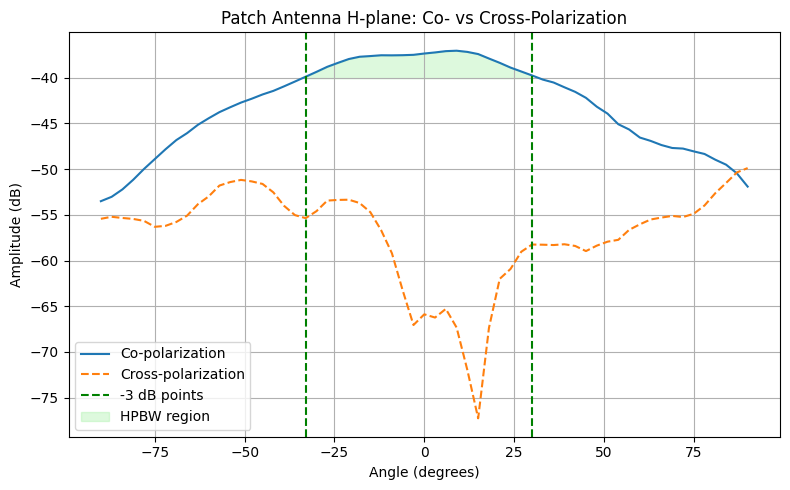

HPBW: 63.00° (from -33.0° to 30.0°)
Nulls found at angles (deg): []
Cross Polarization Suppression (XPS): 16.30 dB
  Co-pol max within HPBW: -37.04 dB
  Cross-pol max within HPBW: -53.34 dB


In [8]:
plot_polarizations(
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/571_Patch1Hplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/571_Patch1Hplane_X.mat',
    title="Patch Antenna H-plane: Co- vs Cross-Polarization",
    prominence=2
)

- Compare the dimesions of the patch with the calculated dimensions from exercise 2

    - The dimensions of the patch antenna were W=46mm and L=50mm. The ones obtained from the calculations were W=59mm and L=48mm.

- Which conclusions can you draw from the shape of the radiation pattern to the current distribution on the antenna?

    - The shape of the radiation pattern in the far field resembles the current distribution over the length of the patch antenna.

- Compare the dimensions of the patch antenna with the calculated dimensions from **Exercise 5.2**.

The dimensions of the patch antenna were W=46mm and L=50mm. The ones obtained from the calculations were W=59mm and L=48mm.

- Extract the following values from the diagram:
    - **Half Power Beam Width** (Co-polarization)
    - **Cross-polarization suppression**

#


| Antenna Type  | Plane   | HPBW (°)            | Nulls (°) | X-Pol Suppression (dB) | Co-pol Max (dB) | X-pol Max (dB) |
|---------------|---------|---------------------|-----------|-------------------------|------------------|----------------|
| Patch antenna | H-plane | 63.0 (−33.0 to 30.0) | —         | 16.30                   | −37.04           | −53.34         |
#### Summary of Measurement Results – Exercise 5.7 (Patch Antenna)

- Analyze the result:
    - What conclusions can you draw from the shape of the radiation pattern regarding the **current distribution** on the antenna?

    The shape of the radiation pattern in the H-plane reflects the fundamental current distribution of a resonant λ/2 patch antenna. Since the patch was designed for an operating frequency of 2 GHz on a Teflon substrate (εᵣ = 2.2, thickness 2.5 mm), its physical length (~22.9 mm) matches the expected half-wavelength in the dielectric medium. This confirms that the antenna operates in its fundamental mode.

    In this mode, the current is maximal at the center and zero at the open ends, resulting in a broad, single-lobed radiation pattern without pronounced sidelobes or multiple nulls. The observed half-power beam width of 63° and the absence of strong ripples in the pattern are characteristic of a single standing wave on the patch. This alignment between theory and measurement supports the conclusion that the patch is well-matched and radiates as a λ/2 resonant element.

### Exercise 5.8 – Patch Array with Phase Shifters (Experiment)

- Record the radiation pattern of the **4×1 patch array** for all **three phase shifter settings** in the **horizontal direction** for **f = 2 GHz**.  

- Print all three measurements (**not normalized**) in **one diagram**.


θ = 90° corresponds to measured relative angle shift of 3.0°. With max amplitude = -32.12dB.
HPBW for θ = 90° is: 21°.
θ = 70° corresponds to measured relative angle shift of -15.0°. With max amplitude = -34.45dB.
HPBW for θ = 70° is: 21°.
θ = 50° corresponds to measured relative angle shift of -34.0°. With max amplitude = -29.42dB.
HPBW for θ = 50° is: 28°.


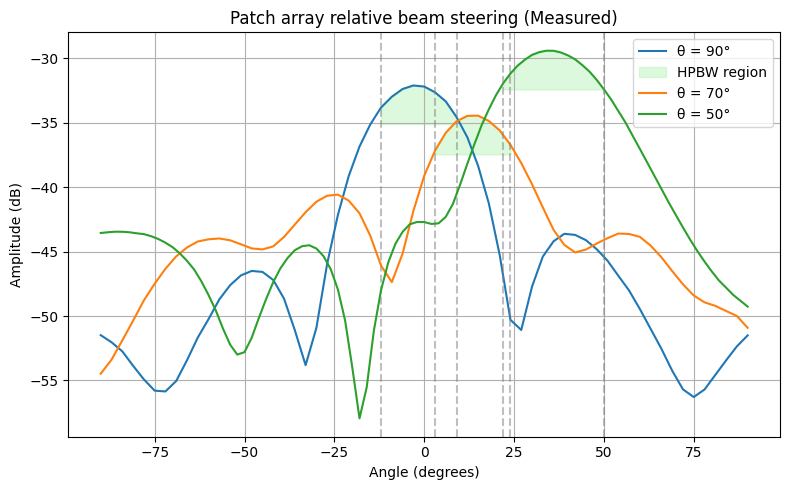

In [9]:
plot_array_patterns(
    paths=[
        'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/581_Patch4Hplane_Co.mat',
        "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/581_Patch4Hplane_62deg_Co.mat",
        "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/581_Patch4Hplane_137deg_Co_twisted.mat"
    ],
    labels=[f"\u03B8 = 90°", f"\u03B8 = 70°", f"\u03B8 = 50°"],
    title="Patch array relative beam steering (Measured)", 
    printL=False,
    printA=True
)

- Determine the **pivoting angles** corresponding to each phase shift.

The pivoting angle $\theta$ is the angle of the main lobe, relative to the horizontal patch antenna array plane. If the main radiation should be rectangular to the patch array plane, the pivoting angle is 90°. This refers to 0° phase shift in the diagram above. 
The measured angles above are relative to the 90° pivoting angle $\theta$. 
The absolute pivoting angles in respect to the patch antenna array plane for each corresponding phase shift are:
- $\theta_{90°}$ = 90° + ( +3°)  = 93° 
- $\theta_{70°}$ = 90° + (-15°) = 75°  
- $\theta_{50°}$ = 90° + (-34°) = 56°


#### Compare the measured results with your calculations from **Exercise 5.3** and explain differences:
Calculations from **Exercise 5.3**:

In [10]:
### CONSTANTS ###
d = 75e-3 ##75mm
theta1 = 90 #90 degree
theta2 = 70 #70 degree
theta3 = 50 #50 degree
epsilon = 2.2
f = 2e9 #2 GHz
c0 = 3e8 #speed of light
wavelength = c0 / f


### Calculation of the needed phase increment

## radiation direction theta1: 
phase_inc_1 = ((-2* np.pi) / wavelength) * d * np.sin(np.deg2rad(theta1))

## radiation direction theta2: 
phase_inc_2 = ((-2* np.pi) / wavelength) * d * np.sin(np.deg2rad(theta2))

## radiation direction theta3: 
phase_inc_3 = ((-2* np.pi) / wavelength) * d * np.sin(np.deg2rad(theta3))

print(f"The phase increment for angle \u03B8_{1} = 90° is: {np.rad2deg(phase_inc_1)+180:.3f}°.")
print(f"The phase increment for angle \u03B8_{2} = 70° is: {np.rad2deg(phase_inc_2)+180:.3f}°.")
print(f"The phase increment for angle \u03B8_{3} = 50° is: {np.rad2deg(phase_inc_3)+180:.3f}°.")


The phase increment for angle θ_1 = 90° is: 0.000°.
The phase increment for angle θ_2 = 70° is: 10.855°.
The phase increment for angle θ_3 = 50° is: 42.112°.


Comparison of measured angle shifts with the calculated angle shifts from Exercise 5.3 to reach pivoting angle $\theta$.

| Pivoting Angle $\theta$  | Calculated phase increment   |Measured phase increment| Corresponding pivoting Angle |  Difference     |
|--------------------------|--------------------------|-----------------------|----------------------|----------------|
|            90°           |           0°             |     +3°    |         +93°          |      3°        |
|            70°           |           10.85°        |     -15°    |         +75°         |      4.15°    |
|            50°           |           42.11°        |     -34°    |         +56°         |      8.11°     |

Explanation of the differences: 
The differences are relatively small. This could be realted to measurement tolerances.
The different sign of the phase increment is probably from the orientation of the measurement setup.


- Analyze the results:
  - How do the three radiation patterns differ in terms of **Half Power Beam Width (HPBW)** and **gain**, and why?

| Pivoting Angle $\theta$  | HPBW            |        Max Amplitude       | 
|--------------------------|-----------------|-----------------------|
|            90°           |           21°        |   -32.12dB      |   
|            70°           |           21°        |    -34.45dB     |       
|            50°           |           28°        |     -29.42dB    |       

- Additionally:
  - Plot the **radiation pattern without phase shift** alongside the single patch result from **Exercise 5.7** in one diagram.

Patch Array: max amplitude = -32.12dB at angle -3.0°
HPBW for Patch Array is: 21°.
Single Patch: max amplitude = -37.04dB at angle 9.0°
HPBW for Single Patch is: 63°.


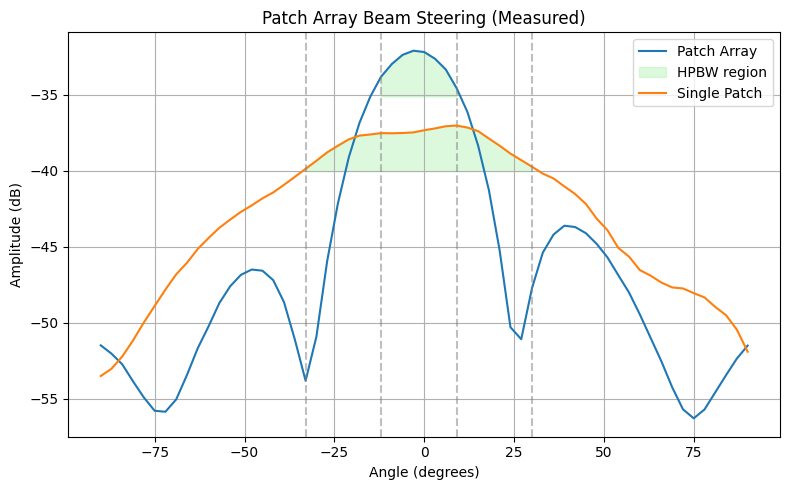

In [11]:
plot_array_patterns(
    paths=[
        'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/581_Patch4Hplane_Co.mat',
        "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/571_Patch1Hplane_Co.mat"
    ],
    labels=["Patch Array", "Single Patch"],
    title="Patch Array Beam Steering (Measured)"
)

  - Estimate the **difference in receive power** in the main radiating direction.
    - The difference is $(-32.12dB) - (-37.04dB) = 4.92dB$
  - How large should this difference theoretically be?
    - Since the number of elements is increased by 4 and so the area increases also by 4. The power should be 2*3 = 6dB.
  - What could be the reasons for any discrepancy?
    - We have around one dB difference, which could be due to mechanical differences from antenna to antenna, interference or just measurement tolerances.

- Compare the **HPBW** of the **single patch** with the **patch array**.
  - The HPBW of the single patch is 63° and for the patch array it is 21°, which is a huge difference.

### Exercise 5.9 – Calibration (Experiment)
- Calculate the number of points, so that the distance between two frequency samples is 25MHz.
    - The number of samples required is 640 measurement points.

- Test your calibration by measuring the gain of the reference antenna and compare it with the data sheet
of the antenna under test.
    - The calibtration measurement results match the data sheets values.     
- Print the gain measurement and comment your comparison with the data sheet.




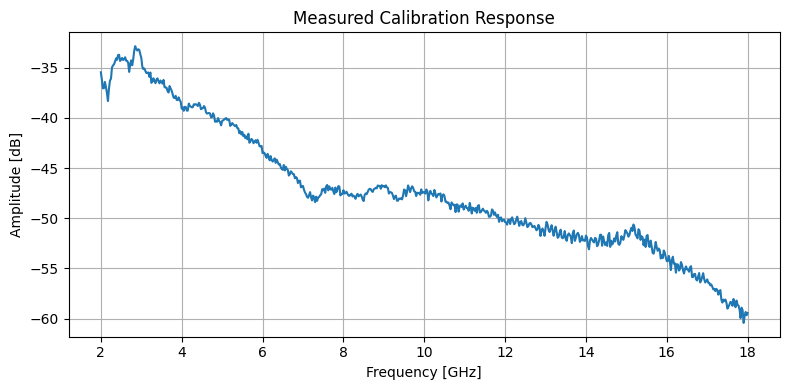

Amplitude at 11.85 GHz: -50.3616 dB


In [12]:
# --- Load data ---
freqs, amps = load_cal_from_mat("Microwave_lab_07_07_25/Measurement_Antennas/591_Calibration_Horizontal.mat")

#--- Plot ---
plt.figure(figsize=(8, 4))
plt.plot(freqs * 1e-9, amps, color='tab:blue')
plt.title("Measured Calibration Response")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Amplitude [dB]") 
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Value at target frequency ---
target_freq = 11.85e9

idx = np.argmin(np.abs(freqs - target_freq))
print(f"Amplitude at 11.85 GHz: {amps[idx]:.4f} dB")


Comparing the calibration results with the datasheet of the AUT shows as expected slight differences but matches it in general.

### Print the gain measurement for both horns in one diagram

C:\Users\luigi\AppData\Local\Temp\ipykernel_30940\1513008253.py:203: RuntimeWarning: divide by zero encountered in log10
  E_dB = 20 * np.log10(np.abs(E))


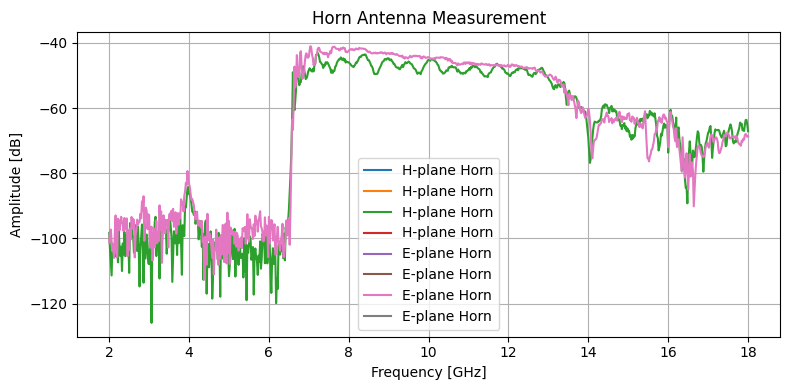

In [13]:
freqs_H, E_dB_H = load_gain_from_mat("Microwave_lab_07_07_25/Measurement_Antennas/Task9/Task9_H_plane_Horn.mat")
freqs_E, E_dB_E = load_gain_from_mat("Microwave_lab_07_07_25/Measurement_Antennas/Task9/Task9_E_plane_Horn.mat")

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot(freqs_H , E_dB_H, label="H-plane Horn") 
plt.plot(freqs_E , E_dB_E, label="E-plane Horn")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Amplitude [dB]")
plt.title("Horn Antenna Measurement")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


- What is the minimum "usable" frequency of both antennas? Explain why.
  - The minimum usable frequency is for both around 7 GHz because the gain drops there significantly.

- For higher frequencies, the gain fluctuates and gets worse. Starting from which frequency does this
effect occur?
   - This effect starts up from around 13 GHz.
- Why is the gain getting worse?
   - This could be due to dimensions of the antenna, which determine the frequency range (according to eqtion 12 of the lab script) and also because the antenna matching is usually also frequency dependent.
- Explain this behavior. (Hint: Is there a correlation between the minimum and maximum "usable"
frequency of the horns?)
   - The excitation and propagation of H10 mode depends on the geometry of the antenna and is limited by a lower and upper frequency. 
   - Also an upper and lower frequency is limiting the matching performance of the antenna. If the power matching is not sufficient, the input reflections of the antenna are high and therefore also the gain drops.
- Compare the gain of both horn antennas.
   - The gain of both antennas is almost identical.

- How big is the difference and where does it originate from?

   There is a difference. The E antenna has a "quasi-flat" gain while there is a ripple in the gain of the antenna extended in the H-Plane of about 3dB. 